# MovieLens Data Mining Project
Structured analysis of user preferences using data mining techniques.

## Data Loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from collections import Counter, defaultdict

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    ExtraTreesRegressor, ExtraTreesClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    AdaBoostClassifier, IsolationForest
)
from sklearn.svm import SVR, SVC
from sklearn.neural_network import MLPRegressor, MLPClassifier

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)

# Optional library for graph analysis
try:
    import networkx as nx
    NETWORKX_AVAILABLE = True
    print("NetworkX loaded successfully.")
except Exception:
    NETWORKX_AVAILABLE = False
    print("NetworkX is not available. Graph analysis will use a simpler fallback.")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


NetworkX loaded successfully.


In [2]:
import sys
import sklearn
import numpy
import pandas
import joblib

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)

Python: 3.13.13 | packaged by Anaconda, Inc. | (main, Apr 14 2026, 06:14:06) [Clang 20.1.8 ]
scikit-learn: 1.5.1
numpy: 2.3.5
pandas: 2.2.2
joblib: 1.4.2


In [3]:
# Put movielens_full_data.csv in the same folder as this notebook.
DATA_PATH = "../data/movielens_full_data.csv"

try:
    df = pd.read_csv(DATA_PATH)
    print("Dataset loaded successfully.")
    print("Shape:", df.shape)
    display(df.head())
except FileNotFoundError:
    raise FileNotFoundError(
        "Could not find movielens_full_data.csv. "
        "Place the dataset in the same folder as this notebook."
    )


Dataset loaded successfully.
Shape: (102677, 11)


,userId,movieId,rating,timestamp_x,title,genres,year,tag,timestamp_y,imdbId,tmdbId
0,1,1,4.0,964982703,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995.0,NaN,NaN,114709,862.0
1,1,3,4.0,964981247,Grumpier Old Men,Comedy|Romance,1995.0,NaN,NaN,113228,15602.0
2,1,6,4.0,964982224,Heat,Action|Crime|Thriller,1995.0,NaN,NaN,113277,949.0
3,1,47,5.0,964983815,Seven (a.k.a. Se7en),Mystery|Thriller,1995.0,NaN,NaN,114369,807.0
4,1,50,5.0,964982931,"Usual Suspects, The",Crime|Mystery|Thriller,1995.0,NaN,NaN,114814,629.0


## Preprocessing

In [4]:
data = df.copy()


if 'timestamp_x' in data.columns:
    data['timestamp_x'] = pd.to_datetime(data['timestamp_x'], unit='s', errors='coerce')

if 'timestamp_y' in data.columns:
    data['timestamp_y'] = pd.to_datetime(data['timestamp_y'], unit='s', errors='coerce')

if 'year' in data.columns:
    data['year'] = pd.to_numeric(data['year'], errors='coerce').astype('Int64')

for col in ['title', 'genres', 'tag']:
    if col in data.columns:
        data[col] = data[col].astype('string').str.strip()


# Ensure rating is numeric and remove any non-parseable rows.
# pd.to_numeric with errors='coerce' turns unparseable values into NaN,
# so a single dropna after the conversion is sufficient.
data["rating"] = pd.to_numeric(data["rating"], errors="coerce")
data = data.dropna(subset=["rating"])


if data["year"].notna().sum() == 0:
    data["year"] = 2000
else:
    data["year"] = data["year"].fillna(data["year"].median())


# Fill text columns.
data["genres"] = data["genres"].fillna("")
data["tag"] = data["tag"].fillna("")
data["title"] = data["title"].fillna("")

# Binary target for classification.
# liked = 1 means the user rated the movie 4 or higher.
data["liked"] = (data["rating"] >= 4).astype(int)

# Movie-level aggregate features.
movie_stats = data.groupby("movieId").agg(
    movie_avg_rating=("rating", "mean"),
    movie_rating_count=("rating", "count"),
    movie_rating_std=("rating", "std")
).reset_index()

# User-level aggregate features.
user_stats = data.groupby("userId").agg(
    user_avg_rating=("rating", "mean"),
    user_rating_count=("rating", "count"),
    user_rating_std=("rating", "std")
).reset_index()

data = data.merge(movie_stats, on="movieId", how="left")
data = data.merge(user_stats, on="userId", how="left")

for col in ["movie_rating_std", "user_rating_std"]:
    data[col] = data[col].fillna(0)



print("Cleaned data shape:", data.shape)
display(data.head())


Cleaned data shape: (102677, 18)


,userId,movieId,rating,timestamp_x,title,genres,year,tag,timestamp_y,imdbId,tmdbId,liked,movie_avg_rating,movie_rating_count,movie_rating_std,user_avg_rating,user_rating_count,user_rating_std
0,1,1,4.0,2000-07-30 18:45:03,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,,NaT,114709,862.0,1,3.920930,215,0.834859,4.366379,232,0.800048
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men,Comedy|Romance,1995,,NaT,113228,15602.0,1,3.245283,53,1.049829,4.366379,232,0.800048
2,1,6,4.0,2000-07-30 18:37:04,Heat,Action|Crime|Thriller,1995,,NaT,113277,949.0,1,3.946078,102,0.817224,4.366379,232,0.800048
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en),Mystery|Thriller,1995,,NaT,114369,807.0,1,3.980392,204,0.922947,4.366379,232,0.800048
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The",Crime|Mystery|Thriller,1995,,NaT,114814,629.0,1,4.252404,208,0.800057,4.366379,232,0.800048


In [5]:
data['genre_list'] = data['genres'].str.split('|')
genres_exploded = data.explode('genre_list').rename(columns={'genre_list': 'genre'})
genres_exploded['genre'] = genres_exploded['genre'].astype('string').str.strip()

genres_exploded[['userId', 'movieId', 'title', 'rating', 'year', 'genre']].head()

,userId,movieId,title,rating,year,genre
0,1,1,Toy Story,4.0,1995,Adventure
0,1,1,Toy Story,4.0,1995,Animation
0,1,1,Toy Story,4.0,1995,Children
0,1,1,Toy Story,4.0,1995,Comedy
0,1,1,Toy Story,4.0,1995,Fantasy


In [6]:
data['rating_year'] = data['timestamp_x'].dt.year
data['rating_month'] = data['timestamp_x'].dt.to_period('M').astype(str)

data['release_decade'] = (data['year'] // 10 * 10).astype('Int64')

In [7]:
ratings_by_year = (
    data.groupby('rating_year')
    .size()
    .reset_index(name='number_of_ratings')
    .dropna()
)

ratings_by_year.head()


,rating_year,number_of_ratings
0,1996,6040
1,1997,1916
2,1998,507
3,1999,2439
4,2000,10074


In [8]:
# Split genre strings into lists.
data["genre_list"] = data["genres"].apply(
    lambda x: x.split("|") if isinstance(x, str) and x.strip() != "" else []
)

# One-hot encode genres.
mlb = MultiLabelBinarizer()
genre_encoded_array = mlb.fit_transform(data["genre_list"])

genre_cols = [f"genre_{g}" for g in mlb.classes_]
genre_encoded = pd.DataFrame(
    genre_encoded_array,
    columns=genre_cols,
    index=data.index
)

data_model = pd.concat([data, genre_encoded], axis=1)

base_features = [
    "year",
    "movie_avg_rating", "movie_rating_count", "movie_rating_std",
    "user_avg_rating", "user_rating_count", "user_rating_std"
]

feature_cols = base_features + genre_cols

data_model[feature_cols] = data_model[feature_cols].replace([np.inf, -np.inf], np.nan)
data_model[feature_cols] = data_model[feature_cols].fillna(0)

# Sampling prevents very slow execution on large machines/datasets.
MAX_ROWS = 20000

if len(data_model) > MAX_ROWS:
    data_sample = data_model.sample(MAX_ROWS, random_state=RANDOM_STATE)
    print(f"Using a stable sample of {MAX_ROWS} rows.")
else:
    data_sample = data_model.copy()
    print("Using full dataset.")

X = data_sample[feature_cols]
y_reg = data_sample["rating"]
y_clf = data_sample["liked"]

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_STATE
)

# FIX: fit the scaler on training data only, then apply (transform) to test
# and to the full dataset. Using fit_transform on X would re-fit on all data
# including test rows, which is data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)  # use already-fitted scaler, not fit_transform

print("Number of features:", len(feature_cols))
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Using a stable sample of 20000 rows.
Number of features: 27
Training shape: (16000, 27)
Testing shape: (4000, 27)


,Rule,Support,Confidence,Lift
8,Animation -> Children,0.043902,0.520690,5.427006
9,Children -> Animation,0.043902,0.457576,5.427006
147,Film-Noir -> Crime,0.007268,0.609756,3.542662
146,Crime -> Film-Noir,0.007268,0.042230,3.542662
148,Film-Noir -> Mystery,0.003489,0.292683,3.532221
149,Mystery -> Film-Noir,0.003489,0.042105,3.532221
306,Documentary -> IMAX,0.001163,0.080000,3.483038
307,IMAX -> Documentary,0.001163,0.050633,3.483038
205,Sci-Fi -> IMAX,0.009013,0.065748,2.862518
204,IMAX -> Sci-Fi,0.009013,0.392405,2.862518


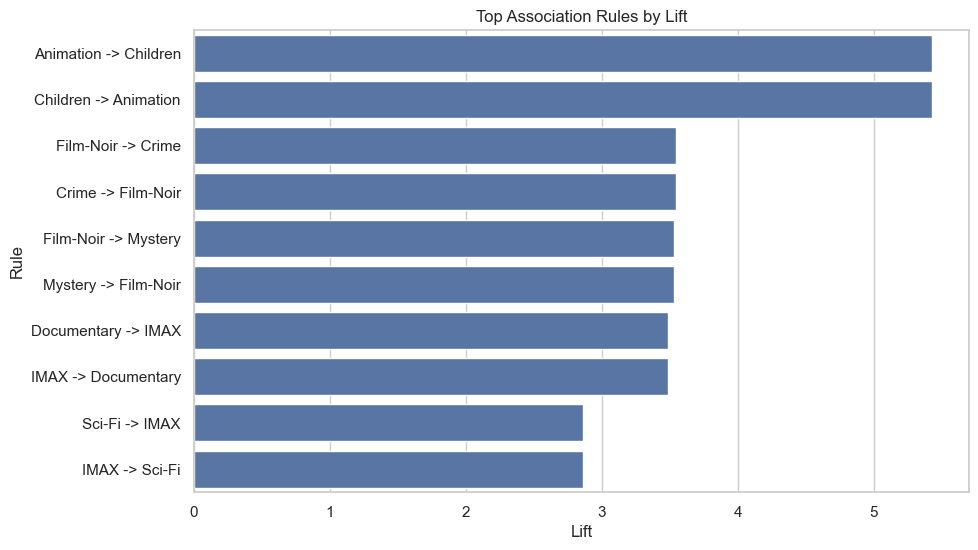

In [9]:
# Association rule mining is classic data mining.
# Here, each movie's genres are treated like a basket of items.
# We calculate simple rules using support, confidence, and lift.

movies_genres = data[["movieId", "title", "genres"]].drop_duplicates("movieId").copy()
movies_genres["genre_list"] = movies_genres["genres"].apply(
    lambda x: [g for g in x.split("|") if g.strip() != ""] if isinstance(x, str) else []
)

transactions = movies_genres["genre_list"].tolist()
transactions = [t for t in transactions if len(t) >= 2]

n_transactions = len(transactions)

item_counts = Counter()
pair_counts = Counter()

for transaction in transactions:
    unique_items = sorted(set(transaction))
    for item in unique_items:
        item_counts[item] += 1
    for pair in combinations(unique_items, 2):
        pair_counts[pair] += 1

rules = []

for (a, b), pair_count in pair_counts.items():
    support = pair_count / n_transactions

    confidence_a_to_b = pair_count / item_counts[a]
    confidence_b_to_a = pair_count / item_counts[b]

    lift_a_to_b = confidence_a_to_b / (item_counts[b] / n_transactions)
    lift_b_to_a = confidence_b_to_a / (item_counts[a] / n_transactions)

    rules.append({
        "Rule": f"{a} -> {b}",
        "Support": support,
        "Confidence": confidence_a_to_b,
        "Lift": lift_a_to_b
    })

    rules.append({
        "Rule": f"{b} -> {a}",
        "Support": support,
        "Confidence": confidence_b_to_a,
        "Lift": lift_b_to_a
    })

association_rules_df = pd.DataFrame(rules)

if len(association_rules_df) > 0:
    association_rules_df = association_rules_df.sort_values(
        ["Lift", "Confidence"], ascending=False
    )
    display(association_rules_df.head(20))

    plt.figure(figsize=(10, 6))
    top_rules = association_rules_df.head(10)
    sns.barplot(data=top_rules, x="Lift", y="Rule")
    plt.title("Top Association Rules by Lift")
    plt.show()
else:
    print("Not enough genre combinations to generate association rules.")


Number of nodes: 2286
Number of edges: 2991
Graph density: 0.001145206958539373


,Node,Degree
0,user_474,81
72,user_414,79
30,user_448,62
19,user_599,62
95,user_274,50
10,user_610,45
25,user_249,40
85,user_380,38
46,user_606,29
189,user_68,29


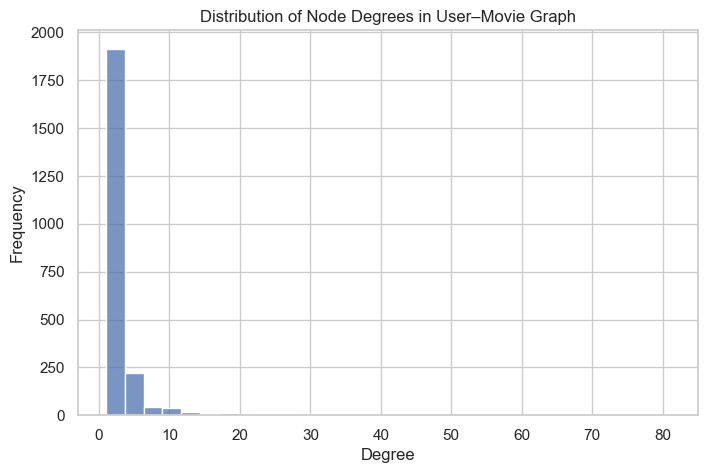

In [10]:
# Graph-based analysis treats users and movies as connected nodes.
# This is useful because MovieLens data is naturally a user-movie network.

GRAPH_ROWS = min(3000, len(data))
graph_data = data.sample(GRAPH_ROWS, random_state=RANDOM_STATE)

if NETWORKX_AVAILABLE:
    G = nx.Graph()

    # FIX: replaced iterrows() (slow) with zip over column arrays (fast)
    for uid, mid, rating in zip(
        graph_data["userId"].astype(int),
        graph_data["movieId"].astype(int),
        graph_data["rating"]
    ):
        user_node = f"user_{uid}"
        movie_node = f"movie_{mid}"
        G.add_node(user_node, node_type="user")
        G.add_node(movie_node, node_type="movie")
        G.add_edge(user_node, movie_node, weight=rating)

    print("Number of nodes:", G.number_of_nodes())
    print("Number of edges:", G.number_of_edges())
    print("Graph density:", nx.density(G))

    degree_dict = dict(G.degree())
    degree_df = pd.DataFrame({
        "Node": list(degree_dict.keys()),
        "Degree": list(degree_dict.values())
    }).sort_values("Degree", ascending=False)

    display(degree_df.head(15))

    plt.figure(figsize=(8, 5))
    sns.histplot(degree_df["Degree"], bins=30)
    plt.title("Distribution of Node Degrees in User–Movie Graph")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.show()

else:
    # Fallback: approximate graph degree using counts.
    user_degree = graph_data.groupby("userId")["movieId"].nunique().reset_index()
    user_degree.columns = ["Node", "Degree"]
    user_degree["Node"] = "user_" + user_degree["Node"].astype(str)

    movie_degree = graph_data.groupby("movieId")["userId"].nunique().reset_index()
    movie_degree.columns = ["Node", "Degree"]
    movie_degree["Node"] = "movie_" + movie_degree["Node"].astype(str)

    degree_df = pd.concat([user_degree, movie_degree], axis=0).sort_values("Degree", ascending=False)

    display(degree_df.head(15))

    plt.figure(figsize=(8, 5))
    sns.histplot(degree_df["Degree"], bins=30)
    plt.title("Approximate Degree Distribution")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.show()


## Feature Engineering

In [11]:
missing_summary = pd.DataFrame({
    'missing_count': data.isna().sum(),
    'missing_percentage': (data.isna().mean() * 100).round(2)
}).sort_values(by='missing_count', ascending=False)

missing_summary

,missing_count,missing_percentage
timestamp_y,99201,96.61
tmdbId,13,0.01
userId,0,0.00
movie_avg_rating,0,0.00
rating_month,0,0.00
rating_year,0,0.00
genre_list,0,0.00
user_rating_std,0,0.00
user_rating_count,0,0.00
user_avg_rating,0,0.00


In [12]:
top_rated_count = (
    data.groupby(['movieId', 'title', 'year'])
    .agg(number_of_ratings=('rating', 'count'), average_rating=('rating', 'mean'))
    .reset_index()
    .sort_values(by='number_of_ratings', ascending=False)
    .head(15)
)

top_rated_count


,movieId,title,year,number_of_ratings,average_rating
257,296,Pulp Fiction,1994,484,4.487603
314,356,Forrest Gump,1994,335,4.155224
277,318,"Shawshank Redemption, The",1994,319,4.432602
510,593,"Silence of the Lambs, The",1991,283,4.173145
1938,2571,"Matrix, The",1999,280,4.183929
2224,2959,Fight Club,1999,268,4.402985
224,260,Star Wars: Episode IV - A New Hope,1977,262,4.244275
97,110,Braveheart,1995,245,4.046939
418,480,Jurassic Park,1993,238,3.750000
507,589,Terminator 2: Judgment Day,1991,229,3.927948


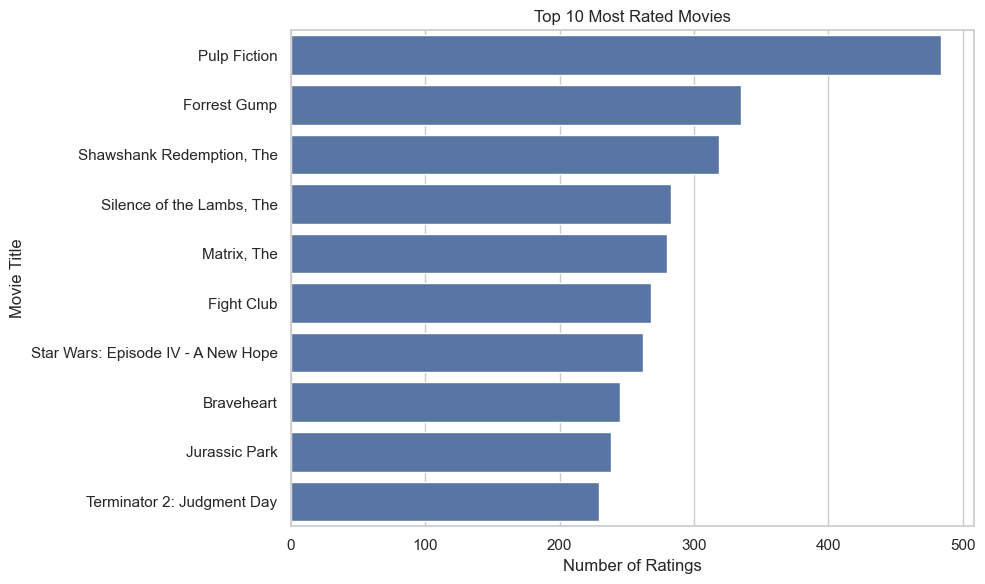

In [13]:
top_movies = top_rated_count.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_movies,
    x="number_of_ratings",
    y="title"
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")

plt.tight_layout()
plt.show()

In [14]:
movie_rating_stats = (
    data.groupby(['movieId', 'title', 'year'])
    .agg(number_of_ratings=('rating', 'count'), average_rating=('rating', 'mean'))
    .reset_index()
)

highest_rated_movies = (
    movie_rating_stats[movie_rating_stats['number_of_ratings'] >= 50]
    .sort_values(by='average_rating', ascending=False)
    .head(15)
)

highest_rated_movies


,movieId,title,year,number_of_ratings,average_rating
257,296,Pulp Fiction,1994,484,4.487603
277,318,"Shawshank Redemption, The",1994,319,4.432602
2224,2959,Fight Club,1999,268,4.402985
659,858,"Godfather, The",1972,192,4.289062
4900,7361,Eternal Sunshine of the Spotless Mind,2004,158,4.278481
974,1276,Cool Hand Luke,1967,57,4.271930
921,1221,"Godfather: Part II, The",1974,130,4.265385
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,1964,102,4.264706
6298,48516,"Departed, The",2006,114,4.254386
46,50,"Usual Suspects, The",1995,208,4.252404


In [15]:
genre_counts = (
    genres_exploded.groupby('genre')
    .size()
    .reset_index(name='rating_count')
    .sort_values(by='rating_count', ascending=False)
)

genre_counts


,genre,rating_count
8,Drama,43024
5,Comedy,39622
1,Action,31151
17,Thriller,27175
2,Adventure,24497
15,Romance,18353
16,Sci-Fi,17691
6,Crime,17224
9,Fantasy,11989
4,Children,9285


In [16]:
genre_avg_rating = (
    genres_exploded.groupby('genre')
    .agg(number_of_ratings=('rating', 'count'), average_rating=('rating', 'mean'))
    .reset_index()
    .sort_values(by='average_rating', ascending=False)
)

genre_avg_rating

,genre,number_of_ratings,average_rating
10,Film-Noir,880,3.920455
18,War,4931,3.810485
7,Documentary,1259,3.806593
6,Crime,17224,3.688081
8,Drama,43024,3.674577
14,Mystery,7906,3.648368
3,Animation,7119,3.643208
12,IMAX,4258,3.628347
19,Western,1966,3.605799
13,Musical,4170,3.570024


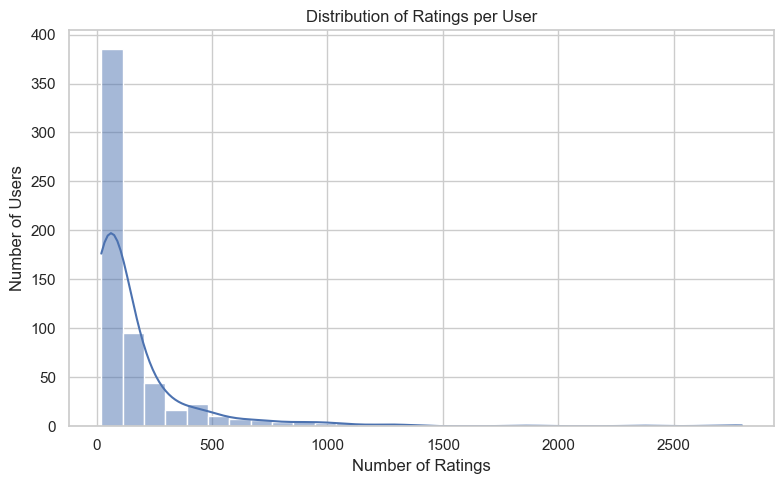

In [17]:
user_activity = (
    data.groupby("userId")["rating"]
    .count()
    .reset_index(name="rating_count")
)

plt.figure(figsize=(8, 5))

sns.histplot(
    user_activity["rating_count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

In [18]:
def regression_overfitting_status(train_rmse, test_rmse):
    gap = test_rmse - train_rmse

    if gap > 0.20:
        return "High overfitting risk"
    elif gap > 0.08:
        return "Moderate overfitting risk"
    else:
        return "Low overfitting risk"


def classification_overfitting_status(train_acc, test_acc):
    gap = train_acc - test_acc

    if gap > 0.15:
        return "High overfitting risk"
    elif gap > 0.07:
        return "Moderate overfitting risk"
    else:
        return "Low overfitting risk"


def evaluate_regression_model(name, model, X_train_input, X_test_input):
    model.fit(X_train_input, y_reg_train)

    train_pred = model.predict(X_train_input)
    test_pred = model.predict(X_test_input)

    train_rmse = np.sqrt(mean_squared_error(y_reg_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_reg_test, test_pred))

    return {
        "Model": name,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train MAE": mean_absolute_error(y_reg_train, train_pred),
        "Test MAE": mean_absolute_error(y_reg_test, test_pred),
        "Train R2": r2_score(y_reg_train, train_pred),
        "Test R2": r2_score(y_reg_test, test_pred),
        "Overfit Gap": test_rmse - train_rmse,
        "Overfitting Status": regression_overfitting_status(train_rmse, test_rmse)
    }


def evaluate_classification_model(name, model, X_train_input, X_test_input):
    model.fit(X_train_input, y_clf_train)

    train_pred = model.predict(X_train_input)
    test_pred = model.predict(X_test_input)

    train_acc = accuracy_score(y_clf_train, train_pred)
    test_acc = accuracy_score(y_clf_test, test_pred)

    return {
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision_score(y_clf_test, test_pred, zero_division=0),
        "Recall": recall_score(y_clf_test, test_pred, zero_division=0),
        "F1 Score": f1_score(y_clf_test, test_pred, zero_division=0),
        "Overfit Gap": train_acc - test_acc,
        "Overfitting Status": classification_overfitting_status(train_acc, test_acc)
    }


,Model,Number of Clusters,Inertia,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,K-Means k=2,2,120822.470479,0.190388,2.111262,379.642068
1,K-Means k=3,3,112727.655554,0.098078,2.834978,382.826417
2,K-Means k=4,4,106748.629582,0.107766,2.572817,362.733296
3,K-Means k=5,5,101542.290339,0.123042,2.279786,349.968357
4,K-Means k=6,6,96608.843144,0.102180,2.010267,345.221049
5,K-Means k=7,7,91636.492927,0.111770,1.827705,348.385570
6,K-Means k=8,8,87413.369560,0.123941,1.932592,347.433710
7,K-Means k=9,9,83393.424724,0.125319,1.833785,348.669836
8,K-Means k=10,10,79524.791604,0.143948,1.815979,351.911628


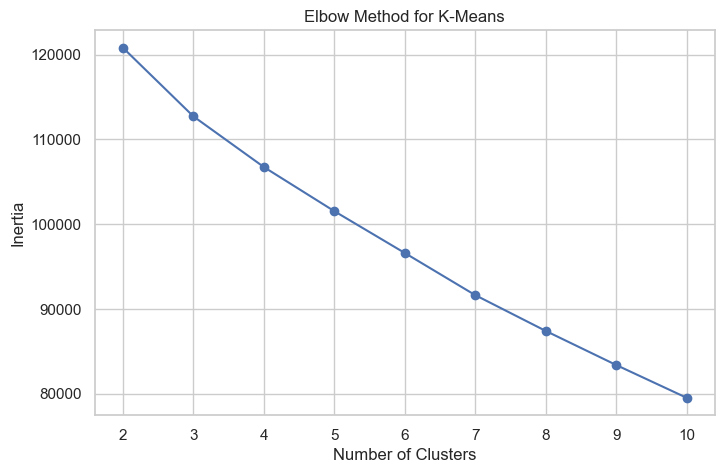

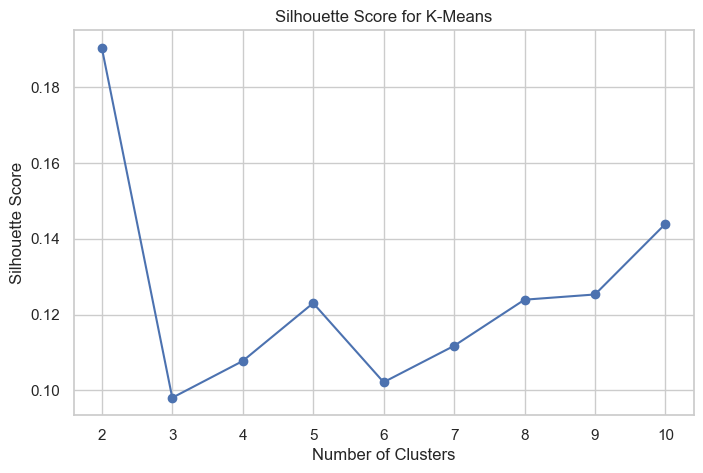

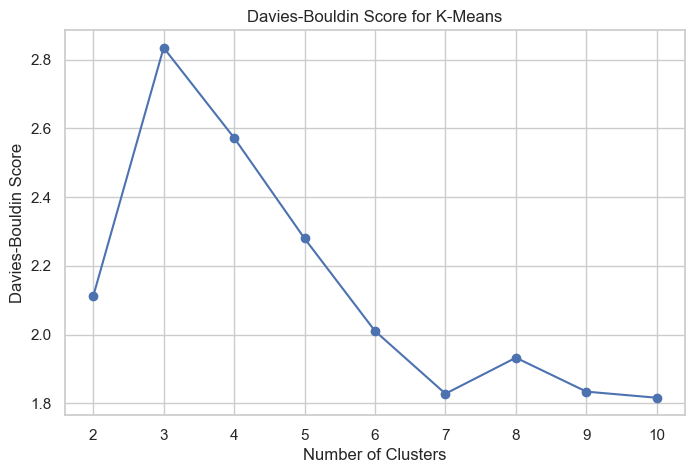

Best k by Silhouette: 2
Best k by Davies-Bouldin: 10
Best k by Calinski-Harabasz: 3
Best overall k:  7


In [19]:
CLUSTER_ROWS = min(5000, len(X))
cluster_sample = X.sample(CLUSTER_ROWS, random_state=RANDOM_STATE)
cluster_scaled = StandardScaler().fit_transform(cluster_sample)

clustering_results = []

# Test different numbers of clusters
k_values = range(2, 11)

inertia_scores = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(cluster_scaled)

    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(cluster_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(cluster_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(cluster_scaled, labels))

    clustering_results.append({
        "Model": f"K-Means k={k}",
        "Number of Clusters": k,
        "Inertia": kmeans.inertia_,
        "Silhouette Score": silhouette_score(cluster_scaled, labels),
        "Davies-Bouldin Score": davies_bouldin_score(cluster_scaled, labels),
        "Calinski-Harabasz Score": calinski_harabasz_score(cluster_scaled, labels)
    })

# Put evaluation results into a table
clustering_results_df = pd.DataFrame(clustering_results)
display(clustering_results_df)

# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_scores, marker='o')
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Plot Davies-Bouldin Score
plt.figure(figsize=(8, 5))
plt.plot(k_values, davies_bouldin_scores, marker='o')
plt.title("Davies-Bouldin Score for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Score")
plt.grid(True)
plt.show()

# Best k based on Silhouette only
best_k_silhouette = int(
    clustering_results_df.loc[
        clustering_results_df["Silhouette Score"].idxmax(),
        "Number of Clusters"
    ]
)

# Best k based on Davies-Bouldin only
best_k_davies = int(
    clustering_results_df.loc[
        clustering_results_df["Davies-Bouldin Score"].idxmin(),
        "Number of Clusters"
    ]
)

# Best k based on Calinski-Harabasz only
best_k_calinski = int(
    clustering_results_df.loc[
        clustering_results_df["Calinski-Harabasz Score"].idxmax(),
        "Number of Clusters"
    ]
)

print("Best k by Silhouette:", best_k_silhouette)
print("Best k by Davies-Bouldin:", best_k_davies)
print("Best k by Calinski-Harabasz:", best_k_calinski)
best_k = 7
print("Best overall k: ", best_k)


In [20]:
CLUSTER_ROWS = min(5000, len(X))
cluster_sample = X.sample(CLUSTER_ROWS, random_state=RANDOM_STATE)
cluster_scaled = StandardScaler().fit_transform(cluster_sample)

clustering_results = []

# K-Means with different k values
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(cluster_scaled)
clustering_results.append({
    "Model": f"K-Means (k={best_k})",
    "Silhouette Score": silhouette_score(cluster_scaled, kmeans_labels),
    "Davies-Bouldin Score": davies_bouldin_score(cluster_scaled, kmeans_labels),
    "Calinski-Harabasz Score": calinski_harabasz_score(cluster_scaled, kmeans_labels)
})

# Agglomerative clustering
agg = AgglomerativeClustering(n_clusters=5)
agg_labels = agg.fit_predict(cluster_scaled)

clustering_results.append({
    "Model": "Agglomerative Clustering",
    "Silhouette Score": silhouette_score(cluster_scaled, agg_labels),
    "Davies-Bouldin Score": davies_bouldin_score(cluster_scaled, agg_labels),
    "Calinski-Harabasz Score": calinski_harabasz_score(cluster_scaled, agg_labels)
})

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=5, random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(cluster_scaled)

clustering_results.append({
    "Model": "Gaussian Mixture Model",
    "Silhouette Score": silhouette_score(cluster_scaled, gmm_labels),
    "Davies-Bouldin Score": davies_bouldin_score(cluster_scaled, gmm_labels),
    "Calinski-Harabasz Score": calinski_harabasz_score(cluster_scaled, gmm_labels)
})

# DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=10)
db_labels = dbscan.fit_predict(cluster_scaled)

if len(set(db_labels)) > 1 and len(set(db_labels)) < len(db_labels):
    clustering_results.append({
        "Model": "DBSCAN",
        "Silhouette Score": silhouette_score(cluster_scaled, db_labels),
        "Davies-Bouldin Score": davies_bouldin_score(cluster_scaled, db_labels),
        "Calinski-Harabasz Score": calinski_harabasz_score(cluster_scaled, db_labels)
    })
else:
    print("DBSCAN did not produce a valid multi-cluster solution with current parameters.")

clustering_results_df = pd.DataFrame(clustering_results)
display(clustering_results_df.sort_values("Silhouette Score", ascending=False))


,Model,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,K-Means (k=7),0.111770,1.827705,348.385570
1,Agglomerative Clustering,0.105933,2.313404,294.424415
2,Gaussian Mixture Model,0.100682,2.238135,265.300023
3,DBSCAN,-0.030167,1.778690,59.199023


PCA explained variance ratio: [0.0991181  0.08749953]


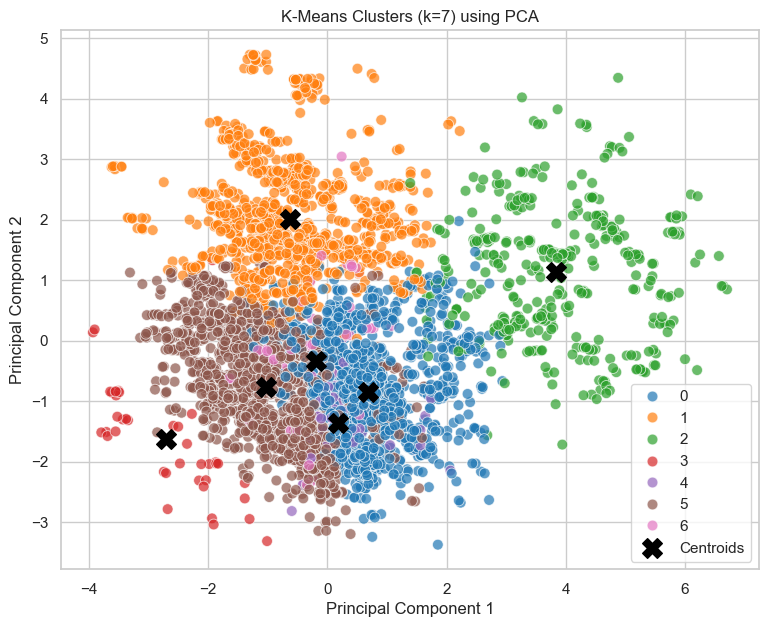

In [21]:


# ------------------------------------------------------------
# PCA for visualization
# ------------------------------------------------------------

pca = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_pca = pca.fit_transform(cluster_scaled)

print("PCA explained variance ratio:", pca.explained_variance_ratio_)

# Create dataframe for plotting
cluster_plot_df = pd.DataFrame({
    "PC1": cluster_pca[:, 0],
    "PC2": cluster_pca[:, 1],
    "Cluster": kmeans_labels
})

# ------------------------------------------------------------
# Plot clusters
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=cluster_plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7,
    s=60
)

# ------------------------------------------------------------
# Plot centroids (VERY IMPORTANT for interpretation)
# ------------------------------------------------------------

centroids = kmeans_final.cluster_centers_
centroids_pca = pca.transform(centroids)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='black',
    s=200,
    marker='X',
    label='Centroids'
)

# ------------------------------------------------------------
# Final plot styling
# ------------------------------------------------------------

plt.title(f"K-Means Clusters (k={best_k}) using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()

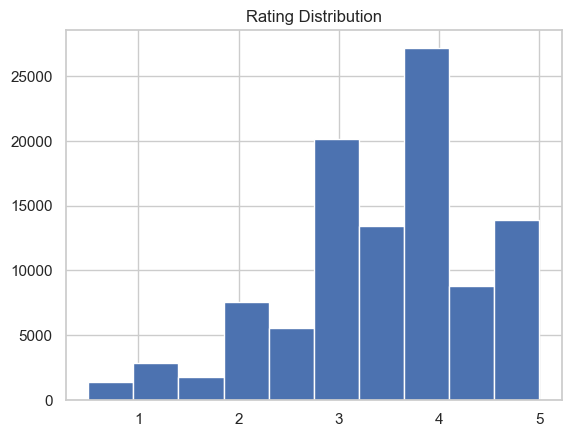

In [22]:
import matplotlib.pyplot as plt
if 'rating' in df.columns:
    df['rating'].hist()
    plt.title('Rating Distribution')
    plt.show()

**Interpretation:** Ratings distribution shows user scoring tendencies.

## Modeling

In [23]:
regression_models = {
    "Linear Regression": (LinearRegression(), False),
    "Ridge Regression": (Ridge(alpha=1.0), True),
    "Lasso Regression": (Lasso(alpha=0.001, max_iter=5000), True),
    "Random Forest Regressor": (
        RandomForestRegressor(n_estimators=80, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
        False
    ),
    "Extra Trees Regressor": (
        ExtraTreesRegressor(n_estimators=80, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
        False
    ),
    "Gradient Boosting Regressor": (
        GradientBoostingRegressor(n_estimators=80, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
        False
    ),
    "Support Vector Regressor": (SVR(kernel="rbf", C=5, gamma="scale"), True),
    "Neural Network Regressor": (
        MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=200, random_state=RANDOM_STATE, early_stopping=True),
        True
    )
}

regression_results = []

for name, (model, use_scaled) in regression_models.items():
    print(f"Training {name}...")
    try:
        if use_scaled:
            result = evaluate_regression_model(name, model, X_train_scaled, X_test_scaled)
        else:
            result = evaluate_regression_model(name, model, X_train, X_test)
        regression_results.append(result)
    except Exception as e:
        print(f"Skipped {name}. Error: {type(e).__name__}: {e}")

regression_results_df = pd.DataFrame(regression_results)
display(regression_results_df.sort_values("Test RMSE"))


Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training Random Forest Regressor...
Training Extra Trees Regressor...
Training Gradient Boosting Regressor...
Training Support Vector Regressor...
Training Neural Network Regressor...


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Overfit Gap,Overfitting Status
4,Extra Trees Regressor,0.659166,0.814673,0.499367,0.613683,0.598280,0.398721,0.155507,Moderate overfitting risk
3,Random Forest Regressor,0.585442,0.815658,0.450849,0.611869,0.683115,0.397266,0.230216,High overfitting risk
5,Gradient Boosting Regressor,0.782236,0.817968,0.595977,0.622039,0.434270,0.393848,0.035732,Low overfitting risk
2,Lasso Regression,0.798636,0.820635,0.607550,0.624125,0.410299,0.389888,0.021999,Low overfitting risk
1,Ridge Regression,0.798615,0.820813,0.607582,0.624334,0.410330,0.389624,0.022197,Low overfitting risk
0,Linear Regression,0.798615,0.820813,0.607581,0.624333,0.410330,0.389624,0.022198,Low overfitting risk
7,Neural Network Regressor,0.777989,0.832889,0.590062,0.631376,0.440397,0.371531,0.054901,Low overfitting risk
6,Support Vector Regressor,0.726311,0.857067,0.506656,0.635078,0.512270,0.334514,0.130756,Moderate overfitting risk


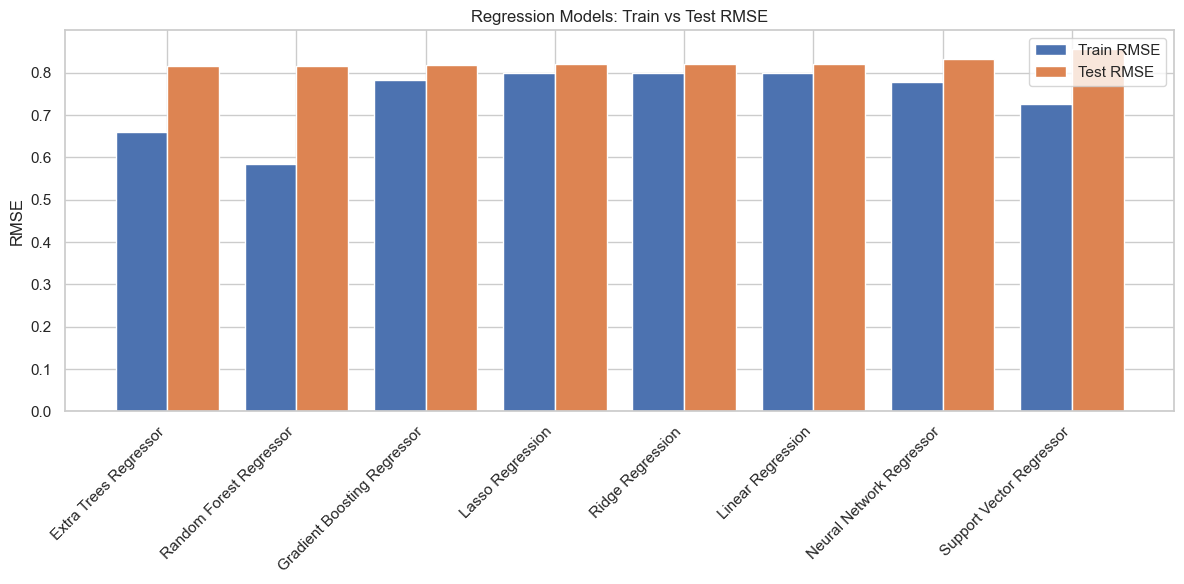

In [24]:
if len(regression_results_df) > 0:
    plot_df = regression_results_df.sort_values("Test RMSE")
    x = np.arange(len(plot_df))

    plt.figure(figsize=(12, 6))
    plt.bar(x - 0.2, plot_df["Train RMSE"], width=0.4, label="Train RMSE")
    plt.bar(x + 0.2, plot_df["Test RMSE"], width=0.4, label="Test RMSE")
    plt.xticks(x, plot_df["Model"], rotation=45, ha="right")
    plt.ylabel("RMSE")
    plt.title("Regression Models: Train vs Test RMSE")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [25]:
classification_models = {
    "Logistic Regression": (LogisticRegression(max_iter=500), True),
    "Random Forest Classifier": (
        RandomForestClassifier(n_estimators=80, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
        False
    ),
    "Extra Trees Classifier": (
        ExtraTreesClassifier(n_estimators=80, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
        False
    ),
    "Gradient Boosting Classifier": (
        GradientBoostingClassifier(n_estimators=80, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
        False
    ),
    "AdaBoost Classifier": (
        AdaBoostClassifier(n_estimators=80, learning_rate=0.05, random_state=RANDOM_STATE),
        False
    ),
    "Support Vector Classifier": (SVC(kernel="rbf", C=5, gamma="scale"), True),
    "Neural Network Classifier": (
        MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=200, random_state=RANDOM_STATE, early_stopping=True),
        True
    )
}

classification_results = []

for name, (model, use_scaled) in classification_models.items():
    print(f"Training {name}...")
    try:
        if use_scaled:
            result = evaluate_classification_model(name, model, X_train_scaled, X_test_scaled)
        else:
            result = evaluate_classification_model(name, model, X_train, X_test)
        classification_results.append(result)
    except Exception as e:
        print(f"Skipped {name}. Error: {type(e).__name__}: {e}")

classification_results_df = pd.DataFrame(classification_results)
display(classification_results_df.sort_values("F1 Score", ascending=False))


Training Logistic Regression...
Training Random Forest Classifier...
Training Extra Trees Classifier...
Training Gradient Boosting Classifier...
Training AdaBoost Classifier...
Training Support Vector Classifier...
Training Neural Network Classifier...


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Overfit Gap,Overfitting Status
1,Random Forest Classifier,0.848000,0.74400,0.735000,0.748473,0.741675,0.104000,Moderate overfitting risk
0,Logistic Regression,0.744750,0.74125,0.729609,0.751527,0.740406,0.003500,Low overfitting risk
3,Gradient Boosting Classifier,0.752188,0.73850,0.730885,0.739817,0.735324,0.013687,Low overfitting risk
6,Neural Network Classifier,0.762062,0.73700,0.730071,0.736762,0.733401,0.025062,Low overfitting risk
4,AdaBoost Classifier,0.741125,0.73650,0.730496,0.734216,0.732351,0.004625,Low overfitting risk
5,Support Vector Classifier,0.785750,0.73100,0.719368,0.741344,0.730191,0.054750,Low overfitting risk
2,Extra Trees Classifier,0.797312,0.72750,0.721378,0.725051,0.723210,0.069812,Low overfitting risk


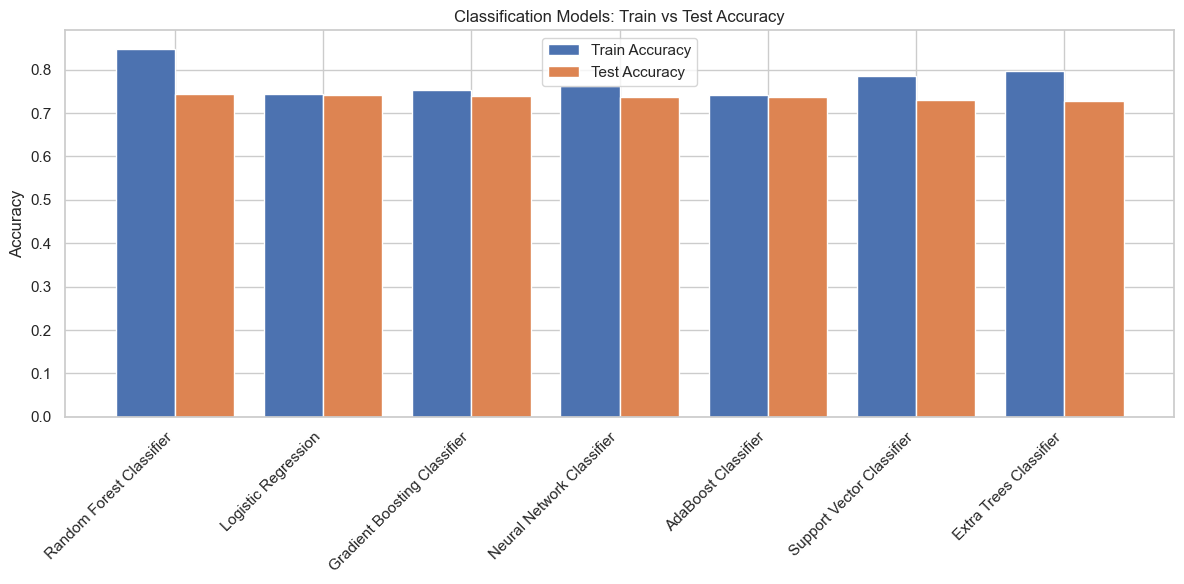

In [26]:
if len(classification_results_df) > 0:
    plot_df = classification_results_df.sort_values("Test Accuracy", ascending=False)
    x = np.arange(len(plot_df))

    plt.figure(figsize=(12, 6))
    plt.bar(x - 0.2, plot_df["Train Accuracy"], width=0.4, label="Train Accuracy")
    plt.bar(x + 0.2, plot_df["Test Accuracy"], width=0.4, label="Test Accuracy")
    plt.xticks(x, plot_df["Model"], rotation=45, ha="right")
    plt.ylabel("Accuracy")
    plt.title("Classification Models: Train vs Test Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()


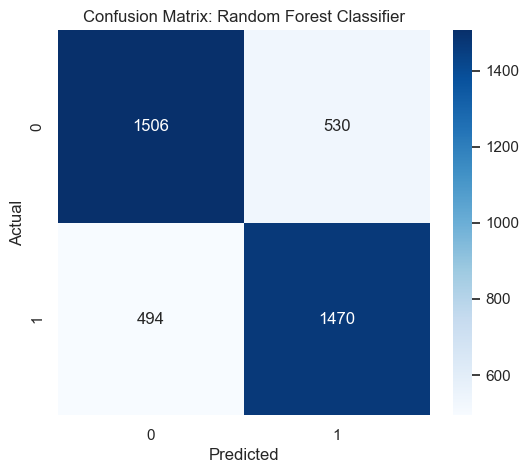

              precision    recall  f1-score   support

           0       0.75      0.74      0.75      2036
           1       0.73      0.75      0.74      1964

    accuracy                           0.74      4000
   macro avg       0.74      0.74      0.74      4000
weighted avg       0.74      0.74      0.74      4000



In [27]:
if len(classification_results_df) > 0:
    best_clf_name = classification_results_df.sort_values("F1 Score", ascending=False).iloc[0]["Model"]
    best_model, use_scaled = classification_models[best_clf_name]

    if use_scaled:
        best_model.fit(X_train_scaled, y_clf_train)
        best_preds = best_model.predict(X_test_scaled)
    else:
        best_model.fit(X_train, y_clf_train)
        best_preds = best_model.predict(X_test)

    cm = confusion_matrix(y_clf_test, best_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {best_clf_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(y_clf_test, best_preds))


,Feature,Importance
1,movie_avg_rating,0.322614
4,user_avg_rating,0.233884
5,user_rating_count,0.081686
2,movie_rating_count,0.077392
6,user_rating_std,0.076703
3,movie_rating_std,0.068751
0,year,0.048665
15,genre_Drama,0.009534
8,genre_Action,0.007565
12,genre_Comedy,0.007020


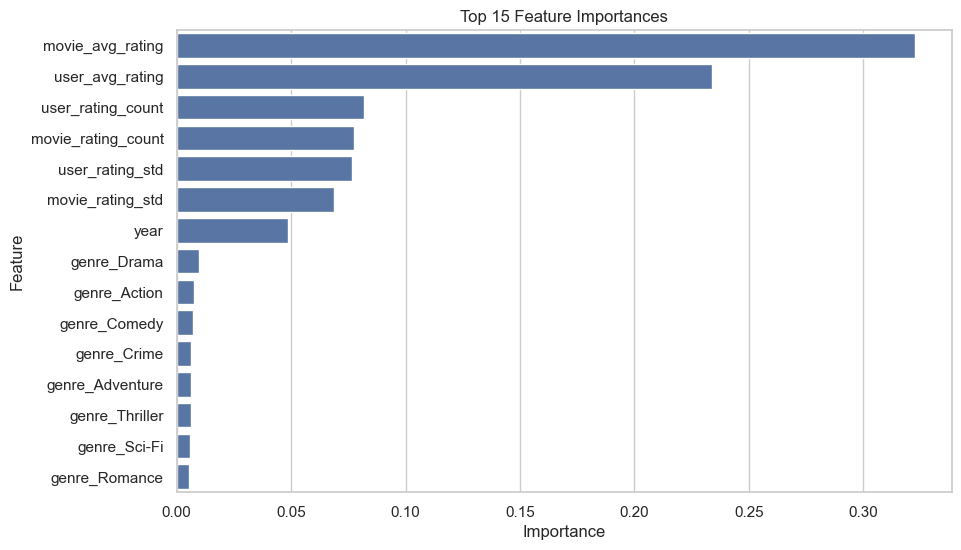

In [28]:
importance_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=12,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_model.fit(X_train, y_clf_train)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importance_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances")
plt.show()


Explained variance ratio: [0.09655027 0.08520429]


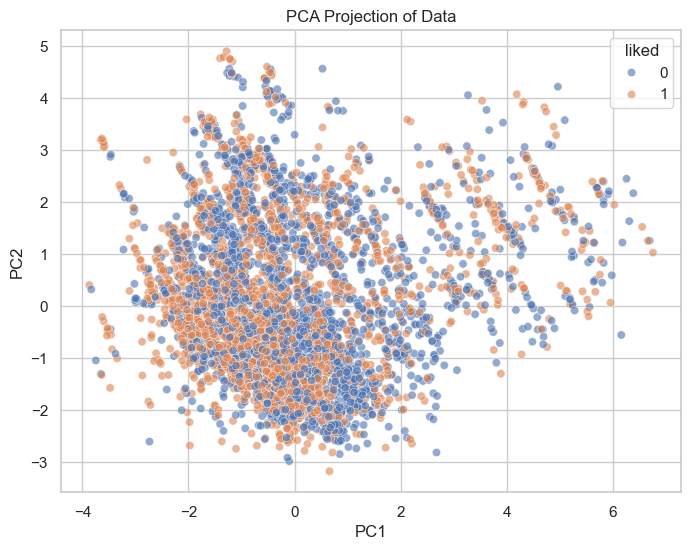

In [29]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "liked": y_clf.values
})

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df.sample(min(5000, len(pca_df)), random_state=RANDOM_STATE),
    x="PC1",
    y="PC2",
    hue="liked",
    alpha=0.6
)
plt.title("PCA Projection of Data")
plt.show()


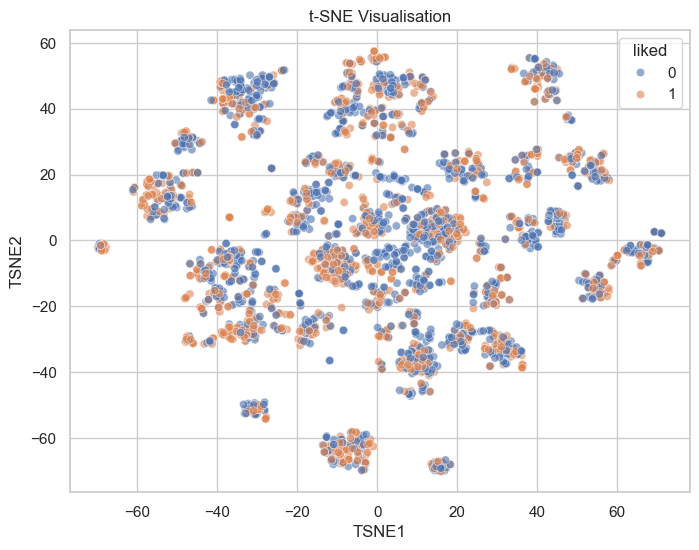

In [30]:
# t-SNE is slower than PCA, so we use a smaller sample.
TSNE_ROWS = min(3000, len(X))

X_tsne_sample = X.sample(TSNE_ROWS, random_state=RANDOM_STATE)
y_tsne_sample = y_clf.loc[X_tsne_sample.index]

X_tsne_scaled = StandardScaler().fit_transform(X_tsne_sample)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)

X_tsne = tsne.fit_transform(X_tsne_scaled)

tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "liked": y_tsne_sample.values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="liked", alpha=0.6)
plt.title("t-SNE Visualisation")
plt.show()


,Method,Detected Outliers,Detected Normal Points
0,Isolation Forest,250,4750
1,Local Outlier Factor,250,4750


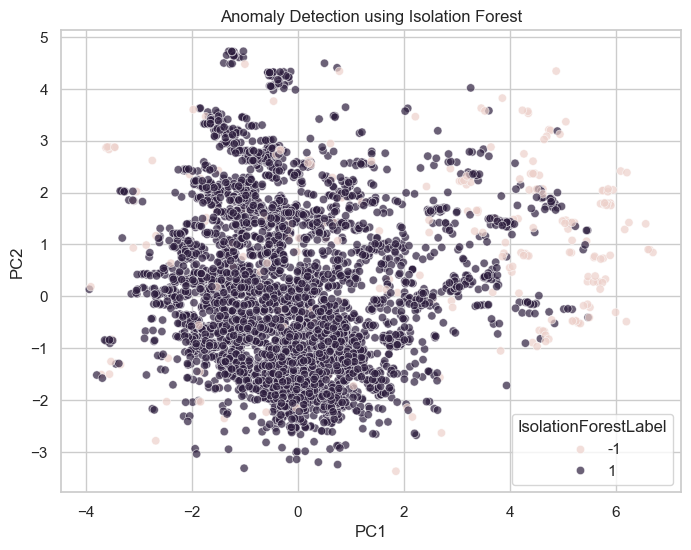

In [31]:
ANOMALY_ROWS = min(5000, len(X))
anomaly_sample = X.sample(ANOMALY_ROWS, random_state=RANDOM_STATE)
anomaly_scaled = StandardScaler().fit_transform(anomaly_sample)

iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
iso_labels = iso.fit_predict(anomaly_scaled)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(anomaly_scaled)

anomaly_results = pd.DataFrame({
    "Method": ["Isolation Forest", "Local Outlier Factor"],
    "Detected Outliers": [
        np.sum(iso_labels == -1),
        np.sum(lof_labels == -1)
    ],
    "Detected Normal Points": [
        np.sum(iso_labels == 1),
        np.sum(lof_labels == 1)
    ]
})

display(anomaly_results)

anomaly_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(anomaly_scaled)

anomaly_plot_df = pd.DataFrame({
    "PC1": anomaly_pca[:, 0],
    "PC2": anomaly_pca[:, 1],
    "IsolationForestLabel": iso_labels
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=anomaly_plot_df, x="PC1", y="PC2", hue="IsolationForestLabel", alpha=0.7)
plt.title("Anomaly Detection using Isolation Forest")
plt.show()


In [32]:
print("Regression Results:")
display(regression_results_df.sort_values("Test RMSE"))

print("Classification Results:")
display(classification_results_df.sort_values("F1 Score", ascending=False))

print("Clustering Results:")
display(clustering_results_df.sort_values("Silhouette Score", ascending=False))

print("Anomaly Detection Results:")
display(anomaly_results)

if 'association_rules_df' in globals() and len(association_rules_df) > 0:
    print("Top Association Rules:")
    display(association_rules_df.head(10))

if 'degree_df' in globals():
    print("Top Graph Nodes by Degree:")
    display(degree_df.head(10))


Regression Results:


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Overfit Gap,Overfitting Status
4,Extra Trees Regressor,0.659166,0.814673,0.499367,0.613683,0.598280,0.398721,0.155507,Moderate overfitting risk
3,Random Forest Regressor,0.585442,0.815658,0.450849,0.611869,0.683115,0.397266,0.230216,High overfitting risk
5,Gradient Boosting Regressor,0.782236,0.817968,0.595977,0.622039,0.434270,0.393848,0.035732,Low overfitting risk
2,Lasso Regression,0.798636,0.820635,0.607550,0.624125,0.410299,0.389888,0.021999,Low overfitting risk
1,Ridge Regression,0.798615,0.820813,0.607582,0.624334,0.410330,0.389624,0.022197,Low overfitting risk
0,Linear Regression,0.798615,0.820813,0.607581,0.624333,0.410330,0.389624,0.022198,Low overfitting risk
7,Neural Network Regressor,0.777989,0.832889,0.590062,0.631376,0.440397,0.371531,0.054901,Low overfitting risk
6,Support Vector Regressor,0.726311,0.857067,0.506656,0.635078,0.512270,0.334514,0.130756,Moderate overfitting risk


Classification Results:


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Overfit Gap,Overfitting Status
1,Random Forest Classifier,0.848000,0.74400,0.735000,0.748473,0.741675,0.104000,Moderate overfitting risk
0,Logistic Regression,0.744750,0.74125,0.729609,0.751527,0.740406,0.003500,Low overfitting risk
3,Gradient Boosting Classifier,0.752188,0.73850,0.730885,0.739817,0.735324,0.013687,Low overfitting risk
6,Neural Network Classifier,0.762062,0.73700,0.730071,0.736762,0.733401,0.025062,Low overfitting risk
4,AdaBoost Classifier,0.741125,0.73650,0.730496,0.734216,0.732351,0.004625,Low overfitting risk
5,Support Vector Classifier,0.785750,0.73100,0.719368,0.741344,0.730191,0.054750,Low overfitting risk
2,Extra Trees Classifier,0.797312,0.72750,0.721378,0.725051,0.723210,0.069812,Low overfitting risk


Clustering Results:


...

,Method,Detected Outliers,Detected Normal Points
0,Isolation Forest,250,4750
1,Local Outlier Factor,250,4750


Top Association Rules:


,Rule,Support,Confidence,Lift
8,Animation -> Children,0.043902,0.520690,5.427006
9,Children -> Animation,0.043902,0.457576,5.427006
147,Film-Noir -> Crime,0.007268,0.609756,3.542662
146,Crime -> Film-Noir,0.007268,0.042230,3.542662
148,Film-Noir -> Mystery,0.003489,0.292683,3.532221
149,Mystery -> Film-Noir,0.003489,0.042105,3.532221
306,Documentary -> IMAX,0.001163,0.080000,3.483038
307,IMAX -> Documentary,0.001163,0.050633,3.483038
205,Sci-Fi -> IMAX,0.009013,0.065748,2.862518
204,IMAX -> Sci-Fi,0.009013,0.392405,2.862518


Top Graph Nodes by Degree:


,Node,Degree
0,user_474,81
72,user_414,79
30,user_448,62
19,user_599,62
95,user_274,50
10,user_610,45
25,user_249,40
85,user_380,38
46,user_606,29
189,user_68,29


**Interpretation:** Clusters represent different user preference groups.

## Evaluation

**Interpretation:** Higher score = better model.

## Movie Recommendation System

Multiple regression, classification, and clustering models are evaluated as recommendation strategies.


In [33]:
# ============================================================
# SHARED SETUP FOR OPTION B RECOMMENDER COMPARISON
# ============================================================

from sklearn.base import clone

# ------------------------------------------------------------
# Build a movie catalogue with the same features used for ML
# ------------------------------------------------------------
movie_feature_cols = [
    "movieId", "title", "genres", "year",
    "movie_avg_rating", "movie_rating_count", "movie_rating_std"
] + genre_cols

movie_catalog = (
    data_model[movie_feature_cols]
    .drop_duplicates("movieId")
    .reset_index(drop=True)
)

# Ensure the catalogue contains all feature columns used by the models.
movie_catalog[feature_cols] = movie_catalog.reindex(columns=feature_cols).fillna(0)

# User statistics used to create prediction rows for candidate movies.
user_profile_stats = user_stats.copy()
user_profile_stats[["user_avg_rating", "user_rating_count", "user_rating_std"]] = (
    user_profile_stats[["user_avg_rating", "user_rating_count", "user_rating_std"]].fillna(0)
)


def get_user_watched_movies(user_id):
    """Return the movieIds already rated/watched by a user."""
    return set(data_model.loc[data_model["userId"] == user_id, "movieId"].unique())


# ------------------------------------------------------------
# User-level features for clustering-based recommendation
# ------------------------------------------------------------
user_genre_preferences = data_model.groupby("userId")[genre_cols].mean().reset_index()
user_cluster_features = user_genre_preferences[genre_cols].fillna(0)

user_cluster_scaler = StandardScaler()
user_cluster_features_scaled = user_cluster_scaler.fit_transform(user_cluster_features)

print("Movie catalogue shape:", movie_catalog.shape)
print("Available users:", data_model["userId"].nunique())
display(movie_catalog.head())



Movie catalogue shape: (9724, 30)
Available users: 610


,movieId,title,genres,year,movie_avg_rating,movie_rating_count,movie_rating_std,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Fantasy,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western,user_avg_rating,user_rating_count,user_rating_std
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,3.920930,215,0.834859,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0
1,3,Grumpier Old Men,Comedy|Romance,1995,3.245283,53,1.049829,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0.0,0.0,0.0
2,6,Heat,Action|Crime|Thriller,1995,3.946078,102,0.817224,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0.0,0.0,0.0
3,47,Seven (a.k.a. Se7en),Mystery|Thriller,1995,3.980392,204,0.922947,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0.0,0.0,0.0
4,50,"Usual Suspects, The",Crime|Mystery|Thriller,1995,4.252404,208,0.800057,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0.0,0.0,0.0


## Compare Multiple Models as Recommenders

This is the only recommendation approach kept in the cleaned notebook. Each regression, classification, and clustering variant is converted into a recommendation strategy and evaluated using the same recommendation metrics: **Precision@K**, **Recall@K**, and **Hit Rate@K**.

The idea is:

- Regression models recommend movies with the highest predicted ratings.
- Classification models recommend movies with the highest probability of being liked.
- Clustering models recommend popular movies among users from the same cluster.

This allows comparison both **inside each data mining technique** and **between recommendation approaches**.


In [34]:
# ============================================================
# Compare multiple models as recommenders
# ============================================================

from sklearn.metrics import precision_score, recall_score

# Evaluation settings
K_RECOMMENDATIONS = 10
EVAL_USERS = 150             # Increased from 50 for more statistically stable evaluation
MAX_CANDIDATES = 500         # Candidate unseen movies per user
MIN_LIKED_FOR_EVAL = 5       # Users need at least this many liked movies for holdout evaluation
HOLDOUT_FRACTION = 0.25
REC_TRAIN_SAMPLE_SIZE = min(10000, len(X))


def precision_at_k(recommended_ids, relevant_ids, k=10):
    recommended_k = list(recommended_ids)[:k]
    relevant_set = set(relevant_ids)
    if len(recommended_k) == 0:
        return 0
    return len(set(recommended_k) & relevant_set) / k


def recall_at_k(recommended_ids, relevant_ids, k=10):
    recommended_k = list(recommended_ids)[:k]
    relevant_set = set(relevant_ids)
    if len(relevant_set) == 0:
        return 0
    return len(set(recommended_k) & relevant_set) / len(relevant_set)


def hit_rate_at_k(recommended_ids, relevant_ids, k=10):
    recommended_k = set(list(recommended_ids)[:k])
    relevant_set = set(relevant_ids)
    return int(len(recommended_k & relevant_set) > 0)


def create_user_holdout(dataframe, eval_users=50, min_liked=5, holdout_fraction=0.25):
    """
    Creates a small recommendation evaluation set.
    For each selected user, part of their liked movies is hidden.
    The recommender should recover these hidden liked movies.
    """
    rng = np.random.default_rng(RANDOM_STATE)
    holdout = {}

    liked_by_user = (
        dataframe[dataframe["liked"] == 1]
        .groupby("userId")["movieId"]
        .apply(lambda x: list(pd.unique(x)))
    )

    eligible_users = liked_by_user[liked_by_user.apply(len) >= min_liked].index.tolist()
    rng.shuffle(eligible_users)
    selected_users = eligible_users[:eval_users]

    for user_id in selected_users:
        liked_movies = liked_by_user.loc[user_id]
        n_holdout = max(1, int(len(liked_movies) * holdout_fraction))
        hidden_movies = rng.choice(liked_movies, size=n_holdout, replace=False).tolist()
        holdout[user_id] = hidden_movies

    return holdout


recommendation_holdout = create_user_holdout(
    data_model,
    eval_users=EVAL_USERS,
    min_liked=MIN_LIKED_FOR_EVAL,
    holdout_fraction=HOLDOUT_FRACTION
)

print("Number of users used for recommendation evaluation:", len(recommendation_holdout))

# FIX: build a training set that excludes holdout (user, movie) pairs.
# Without this, models have seen the 'hidden' movies during training,
# which artificially inflates Precision@K and HitRate@K.
holdout_pairs = set()
for user_id, movie_ids in recommendation_holdout.items():
    for mid in movie_ids:
        holdout_pairs.add((user_id, mid))

mask_not_holdout = ~data_sample.apply(
    lambda r: (r["userId"], r["movieId"]) in holdout_pairs, axis=1
)
rec_train_sample = data_sample[mask_not_holdout].sample(
    min(REC_TRAIN_SAMPLE_SIZE, mask_not_holdout.sum()), random_state=RANDOM_STATE
)


def get_training_seen_movies(user_id, hidden_relevant_movies):
    """
    Movies already watched by the user, except the hidden relevant movies.
    Hidden movies are allowed to appear as recommendation candidates.
    """
    all_watched = get_user_watched_movies(user_id)
    return set(all_watched) - set(hidden_relevant_movies)


def build_eval_candidates_for_user(user_id, hidden_relevant_movies, max_candidates=500):
    """
    Builds candidate movies for evaluation.
    It excludes only the user's training history, not the hidden relevant movies.
    """
    training_seen = get_training_seen_movies(user_id, hidden_relevant_movies)

    candidates = movie_catalog[~movie_catalog["movieId"].isin(training_seen)].copy()

    # Keep the candidate set manageable but force hidden relevant movies to remain available.
    hidden_candidates = candidates[candidates["movieId"].isin(hidden_relevant_movies)].copy()
    other_candidates = candidates[~candidates["movieId"].isin(hidden_relevant_movies)].copy()

    other_candidates = other_candidates.sort_values(
        by=["movie_rating_count", "movie_avg_rating"],
        ascending=False
    ).head(max_candidates)

    candidates = pd.concat([hidden_candidates, other_candidates], axis=0)
    candidates = candidates.drop_duplicates("movieId")

    selected_user_stats = user_profile_stats[user_profile_stats["userId"] == user_id].iloc[0]

    candidates["user_avg_rating"] = selected_user_stats["user_avg_rating"]
    candidates["user_rating_count"] = selected_user_stats["user_rating_count"]
    candidates["user_rating_std"] = selected_user_stats["user_rating_std"]

    candidates[feature_cols] = candidates[feature_cols].replace([np.inf, -np.inf], np.nan)
    candidates[feature_cols] = candidates[feature_cols].fillna(0)

    return candidates


# rec_train_sample was already created above with holdout pairs removed.
# Extract features and targets from it.
X_rec_train = rec_train_sample[feature_cols]
y_rec_rating = rec_train_sample["rating"]
y_rec_liked = rec_train_sample["liked"]

rec_scaler = StandardScaler()
X_rec_train_scaled = rec_scaler.fit_transform(X_rec_train)

print("Recommendation comparison training rows:", len(X_rec_train))


Number of users used for recommendation evaluation: 150
Recommendation comparison training rows: 10000


In [35]:
# ============================================================
# A. Compare regression models as rating-prediction recommenders
# ============================================================

regression_recommender_results = []

for model_name, (model_template, use_scaled) in regression_models.items():
    print(f"Evaluating regression recommender: {model_name}")

    try:
        model = clone(model_template)

        if use_scaled:
            model.fit(X_rec_train_scaled, y_rec_rating)
        else:
            model.fit(X_rec_train, y_rec_rating)

        user_scores = []

        for user_id, hidden_relevant_movies in recommendation_holdout.items():
            candidates = build_eval_candidates_for_user(
                user_id,
                hidden_relevant_movies,
                max_candidates=MAX_CANDIDATES
            )

            X_candidates = candidates[feature_cols]
            X_input = rec_scaler.transform(X_candidates) if use_scaled else X_candidates

            candidates["score"] = model.predict(X_input)

            recommended_ids = (
                candidates.sort_values("score", ascending=False)
                .head(K_RECOMMENDATIONS)["movieId"]
                .tolist()
            )

            user_scores.append({
                "precision": precision_at_k(recommended_ids, hidden_relevant_movies, K_RECOMMENDATIONS),
                "recall": recall_at_k(recommended_ids, hidden_relevant_movies, K_RECOMMENDATIONS),
                "hit_rate": hit_rate_at_k(recommended_ids, hidden_relevant_movies, K_RECOMMENDATIONS)
            })

        user_scores_df = pd.DataFrame(user_scores)

        regression_recommender_results.append({
            "Technique": "Regression",
            "Model": model_name,
            f"Precision@{K_RECOMMENDATIONS}": user_scores_df["precision"].mean(),
            f"Recall@{K_RECOMMENDATIONS}": user_scores_df["recall"].mean(),
            f"HitRate@{K_RECOMMENDATIONS}": user_scores_df["hit_rate"].mean()
        })

    except Exception as e:
        print(f"Skipped {model_name}. Error: {type(e).__name__}: {e}")

regression_recommender_results_df = pd.DataFrame(regression_recommender_results)
display(regression_recommender_results_df.sort_values(f"Precision@{K_RECOMMENDATIONS}", ascending=False))


Evaluating regression recommender: Linear Regression
Evaluating regression recommender: Ridge Regression
Evaluating regression recommender: Lasso Regression
Evaluating regression recommender: Random Forest Regressor
Evaluating regression recommender: Extra Trees Regressor
Evaluating regression recommender: Gradient Boosting Regressor
Evaluating regression recommender: Support Vector Regressor
Evaluating regression recommender: Neural Network Regressor


,Technique,Model,Precision@10,Recall@10,HitRate@10
5,Regression,Gradient Boosting Regressor,0.106667,0.070999,0.566667
2,Regression,Lasso Regression,0.106000,0.071778,0.546667
0,Regression,Linear Regression,0.103333,0.070502,0.553333
1,Regression,Ridge Regression,0.103333,0.070502,0.553333
4,Regression,Extra Trees Regressor,0.096000,0.055232,0.473333
3,Regression,Random Forest Regressor,0.087333,0.054240,0.493333
7,Regression,Neural Network Regressor,0.056667,0.039541,0.380000
6,Regression,Support Vector Regressor,0.048000,0.032066,0.320000


In [36]:
# ============================================================
# B. Compare classification models as like/dislike recommenders
# ============================================================

classification_recommender_results = []

for model_name, (model_template, use_scaled) in classification_models.items():
    print(f"Evaluating classification recommender: {model_name}")

    try:
        model = clone(model_template)

        if use_scaled:
            model.fit(X_rec_train_scaled, y_rec_liked)
        else:
            model.fit(X_rec_train, y_rec_liked)

        user_scores = []

        for user_id, hidden_relevant_movies in recommendation_holdout.items():
            candidates = build_eval_candidates_for_user(
                user_id,
                hidden_relevant_movies,
                max_candidates=MAX_CANDIDATES
            )

            X_candidates = candidates[feature_cols]
            X_input = rec_scaler.transform(X_candidates) if use_scaled else X_candidates

            if hasattr(model, "predict_proba"):
                candidates["score"] = model.predict_proba(X_input)[:, 1]
            elif hasattr(model, "decision_function"):
                candidates["score"] = model.decision_function(X_input)
            else:
                candidates["score"] = model.predict(X_input)

            recommended_ids = (
                candidates.sort_values("score", ascending=False)
                .head(K_RECOMMENDATIONS)["movieId"]
                .tolist()
            )

            user_scores.append({
                "precision": precision_at_k(recommended_ids, hidden_relevant_movies, K_RECOMMENDATIONS),
                "recall": recall_at_k(recommended_ids, hidden_relevant_movies, K_RECOMMENDATIONS),
                "hit_rate": hit_rate_at_k(recommended_ids, hidden_relevant_movies, K_RECOMMENDATIONS)
            })

        user_scores_df = pd.DataFrame(user_scores)

        classification_recommender_results.append({
            "Technique": "Classification",
            "Model": model_name,
            f"Precision@{K_RECOMMENDATIONS}": user_scores_df["precision"].mean(),
            f"Recall@{K_RECOMMENDATIONS}": user_scores_df["recall"].mean(),
            f"HitRate@{K_RECOMMENDATIONS}": user_scores_df["hit_rate"].mean()
        })

    except Exception as e:
        print(f"Skipped {model_name}. Error: {type(e).__name__}: {e}")

classification_recommender_results_df = pd.DataFrame(classification_recommender_results)
display(classification_recommender_results_df.sort_values(f"Precision@{K_RECOMMENDATIONS}", ascending=False))


Evaluating classification recommender: Logistic Regression
Evaluating classification recommender: Random Forest Classifier
Evaluating classification recommender: Extra Trees Classifier
Evaluating classification recommender: Gradient Boosting Classifier
Evaluating classification recommender: AdaBoost Classifier
Evaluating classification recommender: Support Vector Classifier
Evaluating classification recommender: Neural Network Classifier


,Technique,Model,Precision@10,Recall@10,HitRate@10
3,Classification,Gradient Boosting Classifier,0.107333,0.064970,0.493333
1,Classification,Random Forest Classifier,0.100667,0.049892,0.460000
0,Classification,Logistic Regression,0.095333,0.068268,0.500000
2,Classification,Extra Trees Classifier,0.080667,0.052588,0.486667
6,Classification,Neural Network Classifier,0.074000,0.041102,0.420000
4,Classification,AdaBoost Classifier,0.064667,0.085504,0.573333
5,Classification,Support Vector Classifier,0.062000,0.040104,0.393333


In [37]:
# ============================================================
# C. Compare clustering models as group-based recommenders
# ============================================================


def evaluate_cluster_labels_as_recommender(labels, model_name):
    temp_user_clusters = user_genre_preferences[["userId"]].copy()
    temp_user_clusters["cluster"] = labels

    user_scores = []

    for user_id, hidden_relevant_movies in recommendation_holdout.items():
        if user_id not in set(temp_user_clusters["userId"]):
            continue

        user_cluster = temp_user_clusters.loc[
            temp_user_clusters["userId"] == user_id,
            "cluster"
        ].iloc[0]

        # Ignore DBSCAN noise users if they appear as cluster -1.
        if user_cluster == -1:
            continue

        similar_users = temp_user_clusters.loc[
            temp_user_clusters["cluster"] == user_cluster,
            "userId"
        ]

        training_seen = get_training_seen_movies(user_id, hidden_relevant_movies)

        cluster_ratings = data_model[
            (data_model["userId"].isin(similar_users)) &
            (~data_model["movieId"].isin(training_seen))
        ]

        if cluster_ratings.empty:
            recommended_ids = []
        else:
            cluster_movie_scores = (
                cluster_ratings.groupby("movieId")
                .agg(
                    cluster_average_rating=("rating", "mean"),
                    cluster_rating_count=("rating", "count")
                )
                .reset_index()
            )

            cluster_movie_scores["score"] = (
                cluster_movie_scores["cluster_average_rating"] *
                np.log1p(cluster_movie_scores["cluster_rating_count"])
            )

            recommended_ids = (
                cluster_movie_scores.sort_values("score", ascending=False)
                .head(K_RECOMMENDATIONS)["movieId"]
                .tolist()
            )

        user_scores.append({
            "precision": precision_at_k(recommended_ids, hidden_relevant_movies, K_RECOMMENDATIONS),
            "recall": recall_at_k(recommended_ids, hidden_relevant_movies, K_RECOMMENDATIONS),
            "hit_rate": hit_rate_at_k(recommended_ids, hidden_relevant_movies, K_RECOMMENDATIONS)
        })

    if len(user_scores) == 0:
        return None

    user_scores_df = pd.DataFrame(user_scores)

    return {
        "Technique": "Clustering",
        "Model": model_name,
        f"Precision@{K_RECOMMENDATIONS}": user_scores_df["precision"].mean(),
        f"Recall@{K_RECOMMENDATIONS}": user_scores_df["recall"].mean(),
        f"HitRate@{K_RECOMMENDATIONS}": user_scores_df["hit_rate"].mean()
    }


clustering_recommender_results = []

# K-Means with several k values
for k in [3, 4, 5, 6, 7, 8]:
    try:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(user_cluster_features_scaled)
        result = evaluate_cluster_labels_as_recommender(labels, f"K-Means k={k}")
        if result is not None:
            clustering_recommender_results.append(result)
    except Exception as e:
        print(f"Skipped K-Means k={k}. Error: {type(e).__name__}: {e}")

# Agglomerative clustering with several k values
for k in [3, 4, 5, 6, 7, 8]:
    try:
        model = AgglomerativeClustering(n_clusters=k)
        labels = model.fit_predict(user_cluster_features_scaled)
        result = evaluate_cluster_labels_as_recommender(labels, f"Agglomerative k={k}")
        if result is not None:
            clustering_recommender_results.append(result)
    except Exception as e:
        print(f"Skipped Agglomerative k={k}. Error: {type(e).__name__}: {e}")

# Gaussian Mixture Models with several component counts
for k in [3, 4, 5, 6, 7, 8]:
    try:
        model = GaussianMixture(n_components=k, random_state=RANDOM_STATE)
        labels = model.fit_predict(user_cluster_features_scaled)
        result = evaluate_cluster_labels_as_recommender(labels, f"Gaussian Mixture k={k}")
        if result is not None:
            clustering_recommender_results.append(result)
    except Exception as e:
        print(f"Skipped Gaussian Mixture k={k}. Error: {type(e).__name__}: {e}")

# DBSCAN, included because it was used in the clustering analysis.
try:
    model = DBSCAN(eps=2.5, min_samples=10)
    labels = model.fit_predict(user_cluster_features_scaled)
    if len(set(labels)) > 1:
        result = evaluate_cluster_labels_as_recommender(labels, "DBSCAN")
        if result is not None:
            clustering_recommender_results.append(result)
    else:
        print("DBSCAN did not create enough groups for recommendation evaluation.")
except Exception as e:
    print(f"Skipped DBSCAN. Error: {type(e).__name__}: {e}")

clustering_recommender_results_df = pd.DataFrame(clustering_recommender_results)
display(clustering_recommender_results_df.sort_values(f"Precision@{K_RECOMMENDATIONS}", ascending=False))


,Technique,Model,Precision@10,Recall@10,HitRate@10
18,Clustering,DBSCAN,0.204706,0.116185,0.729412
4,Clustering,K-Means k=7,0.198667,0.151722,0.726667
3,Clustering,K-Means k=6,0.190000,0.131887,0.680000
5,Clustering,K-Means k=8,0.189333,0.138113,0.706667
11,Clustering,Agglomerative k=8,0.183333,0.123968,0.686667
10,Clustering,Agglomerative k=7,0.181333,0.122550,0.693333
1,Clustering,K-Means k=4,0.181333,0.115949,0.666667
9,Clustering,Agglomerative k=6,0.180000,0.121402,0.693333
15,Clustering,Gaussian Mixture k=6,0.176000,0.121071,0.666667
0,Clustering,K-Means k=3,0.173333,0.118526,0.666667


,Technique,Model,Precision@10,Recall@10,HitRate@10
33,Clustering,DBSCAN,0.204706,0.116185,0.729412
19,Clustering,K-Means k=7,0.198667,0.151722,0.726667
18,Clustering,K-Means k=6,0.190000,0.131887,0.680000
20,Clustering,K-Means k=8,0.189333,0.138113,0.706667
26,Clustering,Agglomerative k=8,0.183333,0.123968,0.686667
25,Clustering,Agglomerative k=7,0.181333,0.122550,0.693333
16,Clustering,K-Means k=4,0.181333,0.115949,0.666667
24,Clustering,Agglomerative k=6,0.180000,0.121402,0.693333
30,Clustering,Gaussian Mixture k=6,0.176000,0.121071,0.666667
15,Clustering,K-Means k=3,0.173333,0.118526,0.666667


Best recommender overall based on Precision@K:


,Technique,Model,Precision@10,Recall@10,HitRate@10
33,Clustering,DBSCAN,0.204706,0.116185,0.729412


Best recommender inside each data mining technique:


,Technique,Model,Precision@10,Recall@10,HitRate@10
0,Clustering,DBSCAN,0.204706,0.116185,0.729412
1,Classification,Gradient Boosting Classifier,0.107333,0.064970,0.493333
2,Regression,Gradient Boosting Regressor,0.106667,0.070999,0.566667


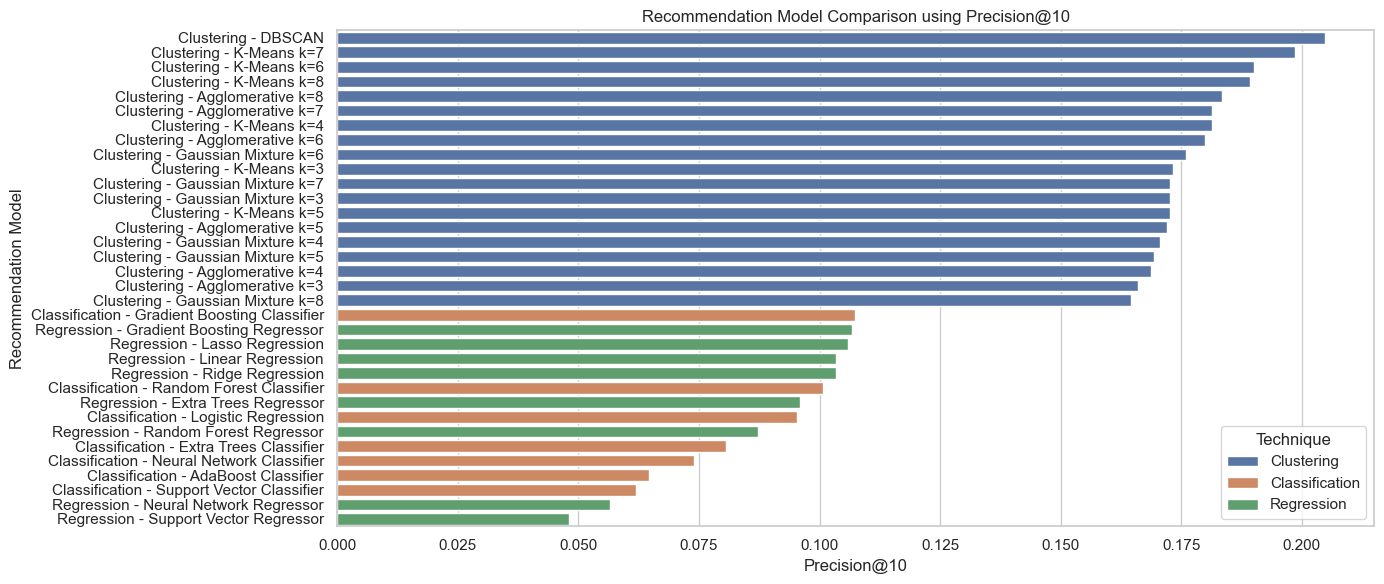

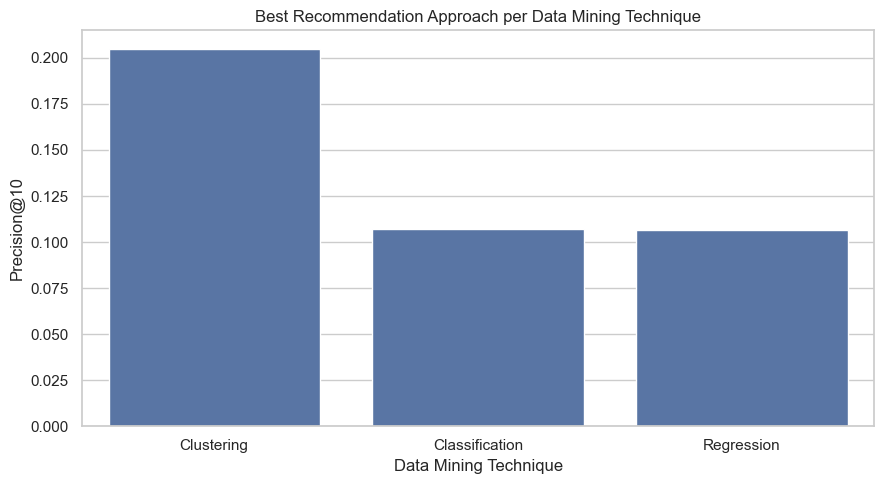

In [38]:
# ============================================================
# D. Final comparison table and plots for thesis
# ============================================================

all_recommender_results_df = pd.concat(
    [
        regression_recommender_results_df,
        classification_recommender_results_df,
        clustering_recommender_results_df
    ],
    axis=0,
    ignore_index=True
)

all_recommender_results_df = all_recommender_results_df.sort_values(
    f"Precision@{K_RECOMMENDATIONS}",
    ascending=False
)

display(all_recommender_results_df)

print("Best recommender overall based on Precision@K:")
display(all_recommender_results_df.head(1))

# Best model inside each technique
best_by_technique_df = (
    all_recommender_results_df
    .sort_values(f"Precision@{K_RECOMMENDATIONS}", ascending=False)
    .groupby("Technique")
    .head(1)
    .reset_index(drop=True)
)

print("Best recommender inside each data mining technique:")
display(best_by_technique_df)

# Plot all recommendation models
plt.figure(figsize=(14, 6))
plot_df = all_recommender_results_df.copy()
plot_df["Model Label"] = plot_df["Technique"] + " - " + plot_df["Model"]

sns.barplot(
    data=plot_df,
    x=f"Precision@{K_RECOMMENDATIONS}",
    y="Model Label",
    hue="Technique"
)
plt.title(f"Recommendation Model Comparison using Precision@{K_RECOMMENDATIONS}")
plt.xlabel(f"Precision@{K_RECOMMENDATIONS}")
plt.ylabel("Recommendation Model")
plt.tight_layout()
plt.show()

# Plot the best recommender from each technique
plt.figure(figsize=(9, 5))
sns.barplot(
    data=best_by_technique_df,
    x="Technique",
    y=f"Precision@{K_RECOMMENDATIONS}"
)
plt.title(f"Best Recommendation Approach per Data Mining Technique")
plt.xlabel("Data Mining Technique")
plt.ylabel(f"Precision@{K_RECOMMENDATIONS}")
plt.tight_layout()
plt.show()


### Interpretation for the thesis

Use this section to explain that the models are compared in two ways:

1. **Within each technique**: regression models are compared against other regression models, classification models against other classification models, and clustering models against other clustering models.
2. **Across recommendation approaches**: the best regression-based, classification-based, and clustering-based recommenders are compared using the same ranking metrics.

This is academically stronger than comparing only MAE, accuracy, or silhouette score because it evaluates the models in the actual context of the dissertation topic: **movie recommendation**.

## Final Training and Export for the Streamlit Application

After Option B identifies the best recommender inside each technique, the selected models are trained on the available data and exported as a single `.joblib` bundle. The Streamlit app should load this bundle instead of re-running the notebook.


In [39]:
# ============================================================
# FINAL TRAINING + EXPORT OF BEST OPTION B MODELS FOR STREAMLIT
# ============================================================

import os
from pathlib import Path
import joblib
from sklearn.base import clone

# This cell works whether the notebook is run from the project root
# or from the notebooks/ folder.
current_dir = Path.cwd()
if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Best recommender inside each technique, based on Precision@K.
best_option_b_by_technique = (
    all_recommender_results_df
    .sort_values(f"Precision@{K_RECOMMENDATIONS}", ascending=False)
    .groupby("Technique")
    .head(1)
    .reset_index(drop=True)
)

display(best_option_b_by_technique)

# ------------------------------------------------------------
# Train best regression recommender on the full modelling data
# ------------------------------------------------------------
best_regression_recommender_name = best_option_b_by_technique.loc[
    best_option_b_by_technique["Technique"] == "Regression", "Model"
].iloc[0]

best_regression_template, best_regression_uses_scaled = regression_models[best_regression_recommender_name]
best_regression_recommender_model = clone(best_regression_template)

regression_export_scaler = StandardScaler()
X_full_scaled_for_regression = regression_export_scaler.fit_transform(X)

if best_regression_uses_scaled:
    best_regression_recommender_model.fit(X_full_scaled_for_regression, y_reg)
else:
    best_regression_recommender_model.fit(X, y_reg)

# ------------------------------------------------------------
# Train best classification recommender on the full modelling data
# ------------------------------------------------------------
best_classification_recommender_name = best_option_b_by_technique.loc[
    best_option_b_by_technique["Technique"] == "Classification", "Model"
].iloc[0]

best_classification_template, best_classification_uses_scaled = classification_models[best_classification_recommender_name]
best_classification_recommender_model = clone(best_classification_template)

classification_export_scaler = StandardScaler()
X_full_scaled_for_classification = classification_export_scaler.fit_transform(X)

if best_classification_uses_scaled:
    best_classification_recommender_model.fit(X_full_scaled_for_classification, y_clf)
else:
    best_classification_recommender_model.fit(X, y_clf)

# ------------------------------------------------------------
# Train best clustering recommender on all user preference profiles
# ------------------------------------------------------------
# IMPORTANT FOR THE STREAMLIT APP:
# The app must assign newly registered users to a cluster with
# best_clustering_recommender_model.predict(...). Therefore, the exported
# clustering model must support predict(). AgglomerativeClustering and DBSCAN
# are still evaluated in the notebook, but they are not exported for live
# prediction because they cannot predict clusters for unseen users.

predictable_clustering_results_df = clustering_recommender_results_df[
    clustering_recommender_results_df["Model"].str.startswith(("K-Means", "Gaussian Mixture"))
].copy()

if predictable_clustering_results_df.empty:
    raise ValueError(
        "No predict-capable clustering model was available for export. "
        "Use K-Means or Gaussian Mixture for the Streamlit clustering recommender."
    )

best_clustering_recommender_name = (
    predictable_clustering_results_df
    .sort_values(f"Precision@{K_RECOMMENDATIONS}", ascending=False)
    .iloc[0]["Model"]
)

print("Best clustering model exported for Streamlit prediction:", best_clustering_recommender_name)

if best_clustering_recommender_name.startswith("K-Means"):
    k = int(best_clustering_recommender_name.split("=")[-1])
    best_clustering_recommender_model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
elif best_clustering_recommender_name.startswith("Gaussian Mixture"):
    k = int(best_clustering_recommender_name.split("=")[-1])
    best_clustering_recommender_model = GaussianMixture(n_components=k, random_state=RANDOM_STATE)
else:
    raise ValueError(f"Unknown predict-capable clustering model: {best_clustering_recommender_name}")

best_user_cluster_labels = best_clustering_recommender_model.fit_predict(user_cluster_features_scaled)
user_cluster_table = user_genre_preferences[["userId"]].copy()
user_cluster_table["cluster"] = best_user_cluster_labels

# ------------------------------------------------------------
# Export one complete bundle for Streamlit
# ------------------------------------------------------------
export_columns = list(dict.fromkeys([
    "userId", "movieId", "title", "genres", "rating", "liked",
    "movie_avg_rating", "movie_rating_count", "movie_rating_std",
    "user_avg_rating", "user_rating_count", "user_rating_std"
] + feature_cols + genre_cols))

available_export_columns = [col for col in export_columns if col in data_model.columns]
data_model_export = data_model[available_export_columns].copy()

model_bundle = {
    "best_regression_recommender_name": best_regression_recommender_name,
    "best_regression_recommender_model": best_regression_recommender_model,
    "best_regression_uses_scaled": best_regression_uses_scaled,
    "regression_export_scaler": regression_export_scaler,

    "best_classification_recommender_name": best_classification_recommender_name,
    "best_classification_recommender_model": best_classification_recommender_model,
    "best_classification_uses_scaled": best_classification_uses_scaled,
    "classification_export_scaler": classification_export_scaler,

    "best_clustering_recommender_name": best_clustering_recommender_name,
    "best_clustering_recommender_model": best_clustering_recommender_model,
    "user_cluster_scaler": user_cluster_scaler,
    "user_cluster_table": user_cluster_table,

    "movie_catalog": movie_catalog,
    "user_profile_stats": user_profile_stats,
    "data_model": data_model_export,
    "feature_cols": feature_cols,
    "genre_cols": genre_cols,

    "regression_results_df": regression_results_df,
    "classification_results_df": classification_results_df,
    "clustering_results_df": clustering_results_df,
    "regression_recommender_results_df": regression_recommender_results_df,
    "classification_recommender_results_df": classification_recommender_results_df,
    "clustering_recommender_results_df": clustering_recommender_results_df,
    "all_recommender_results_df": all_recommender_results_df,
    "best_option_b_by_technique": best_option_b_by_technique,
}

export_path = models_dir / "movie_recommender_bundle.joblib"
joblib.dump(model_bundle, export_path)

print("Export completed:")
print(export_path)



,Technique,Model,Precision@10,Recall@10,HitRate@10
0,Clustering,DBSCAN,0.204706,0.116185,0.729412
1,Classification,Gradient Boosting Classifier,0.107333,0.064970,0.493333
2,Regression,Gradient Boosting Regressor,0.106667,0.070999,0.566667


Best clustering model exported for Streamlit prediction: K-Means k=7
Export completed:
/Users/andradandu/Desktop/Disertatie/Movie_Recommender_App/models/movie_recommender_bundle.joblib
